In [1]:
from pathlib import Path
import sys
import importlib

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


NB_DIR = Path.cwd().resolve()
PROJECT_DIR = NB_DIR.parent.parent
FLOW_DIR = PROJECT_DIR / "z.flow_postprocessing"
FLOW_SCRIPTS_DIR = FLOW_DIR / "scripts"

for path in [PROJECT_DIR, FLOW_SCRIPTS_DIR]:
    path = str(path)
    if path not in sys.path:
        sys.path.insert(0, path)

import theme.plot_theme as ptheme
import shcherbina_utils as shu

importlib.reload(ptheme)
ptheme.apply_theme()
importlib.reload(shu)
shu.apply_plot_style()

print(f"Notebook dir     : {NB_DIR}")
print(f"Project dir      : {PROJECT_DIR}")
print(f"Flow scripts dir : {FLOW_SCRIPTS_DIR}")



Notebook dir     : C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\notebooks
Project dir      : C:\Users\Jelle Gortemaker\Documents\Thesis
Flow scripts dir : C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\scripts


In [2]:
# ============================================================
# SETTINGS
# ============================================================

NB_DIR = Path.cwd().resolve()
INPUT_DIR = (NB_DIR / "../data/input").resolve()

RUN_TITLE_INFO = "Pre- vs. post-adjustment phase comparison"

case_stems = {
    "aug1_production": "run_aug1_production",
    "aug1_spinup": "run_aug1_spinup",
}

case_labels = {
    "aug1_production": "Production phase (AUG-1)",
    "aug1_spinup": "Adjustment phase (AUG-1)",
}

# Select which cases should actually be included in the figure.
# Comment out cases that you do not want to plot.
enabled_cases = [
    "aug1_production",
    "aug1_spinup",
]

case_files = {
    case_key: INPUT_DIR / f"{case_stems[case_key]}.nc"
    for case_key in enabled_cases
}

# Keep labels only for enabled cases.
case_labels = {
    case_key: case_labels[case_key]
    for case_key in enabled_cases
}


# ============================================================
# FILE CHECK
# ============================================================

missing_files = {
    case_key: path
    for case_key, path in case_files.items()
    if not path.exists()
}

print(f"Input directory: {INPUT_DIR}")

print("\nSelected cases:")
for case_key, path in case_files.items():
    status = "FOUND" if path.exists() else "MISSING"
    print(
        f"  {case_labels[case_key]:10s} | "
        f"{status:7s} | {path.name}"
    )

if missing_files:
    missing_text = "\n".join(
        f"  {case_key}: {path}"
        for case_key, path in missing_files.items()
    )

    raise FileNotFoundError(
        "The following input files were not found:\n"
        f"{missing_text}\n\n"
        "Adjust the corresponding entries in case_stems so that "
        "they match the filenames in the data/input folder."
    )


Input directory: C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\data\input

Selected cases:
  Production phase (AUG-1) | FOUND   | run_aug1_production.nc
  Adjustment phase (AUG-1) | FOUND   | run_aug1_spinup.nc



Processing: Production phase (AUG-1)
File      : C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\data\input\run_aug1_production.nc
{'frequency_units': 'cycles day^-1', 'period_units': 'days', 'velocity_units': 'm s^-1', 'temporal_power_units': 'm^2 s^-2', 'spectral_density_units': '(m^2 s^-2)/(cycles day^-1)', 'frequency_bin_width_cycles_per_day': 0.05, 'dt_seconds': 10800.0, 'dt_hours': 3.0, 'nt': 160, 'duration_days': 19.875, 'ny_used': 512, 'nx_used': 512, 'remove_mean': True, 'detrend_linear': False, 'method': 'temporal_rfft_velocity_then_horizontal_power_average', 'normalization': '0.5*(|u_hat|^2+|v_hat|^2)/nt^2, spatially averaged'}

Processing: Adjustment phase (AUG-1)
File      : C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\data\input\run_aug1_spinup.nc
{'frequency_units': 'cycles day^-1', 'period_units': 'days', 'velocity_units': 'm s^-1', 'temporal_power_units': 'm^2 s^-2', 'spectral_density_units': '(m^2 s^-2)/(cycles day^-1)', 'frequenc

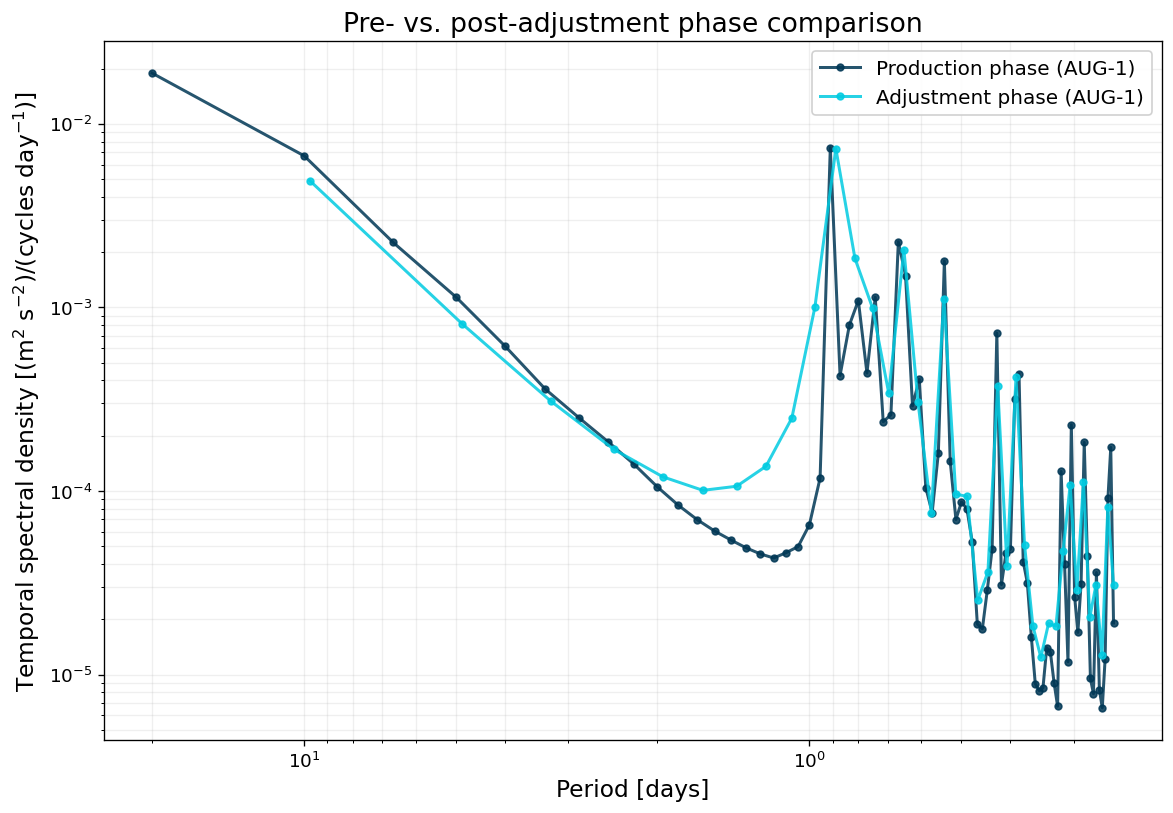

(<Figure size 1200x840 with 1 Axes>,
 <Axes: title={'center': 'Pre- vs. post-adjustment phase comparison'}, xlabel='Period [days]', ylabel='Temporal spectral density [(m$^2$ s$^{-2}$)/(cycles day$^{-1}$)]'>)

In [ ]:
# ============================================================
# COMPUTE AND COMPARE FULL-RUN TEMPORAL SPECTRA
# ============================================================

import warnings

SECONDS_PER_DAY = 86400.0


def calculate_temporal_velocity_spectrum(
    ds,
    u_name="UVEL",
    v_name="VVEL",
    time_dim="T",
    z_index=0,
    remove_mean=True,
    detrend_linear=False,
):
    """
    Calculate a domain-mean temporal surface-velocity spectrum.

    The velocity remains in m s^-1. Frequency is converted from cycles
    per second to cycles per day, so the spectral density has units

        (m^2 s^-2) / (cycles day^-1).

    Parameters
    ----------
    ds : xr.Dataset
        Dataset containing the MITgcm velocity fields.
    u_name, v_name : str
        Names of the horizontal velocity variables.
    time_dim : str
        Name of the temporal dimension.
    z_index : int
        Vertical layer index. Use 0 for the surface layer.
    remove_mean : bool
        Remove the temporal mean at each horizontal grid point.
    detrend_linear : bool
        Optionally remove a linear temporal trend.

    Returns
    -------
    xr.Dataset
        Dataset containing temporal power, spectral density,
        frequency in cycles per day and period in days.
    """

    u = ds[u_name]
    v = ds[v_name]

    if time_dim not in u.dims:
        raise ValueError(
            f"{time_dim=} not found in {u_name} dims: {u.dims}"
        )

    if time_dim not in v.dims:
        raise ValueError(
            f"{time_dim=} not found in {v_name} dims: {v.dims}"
        )

    if not isinstance(z_index, (int, np.integer)):
        raise TypeError(
            f"z_index must be an integer layer index, got {z_index!r}."
        )

    # Put time first.
    u = u.transpose(time_dim, ...)
    v = v.transpose(time_dim, ...)

    u_arr = u.values.astype(float)
    v_arr = v.values.astype(float)

    # MITgcm/MNC commonly gives (time, z, y, x).
    if u_arr.ndim == 4:
        if not 0 <= z_index < u_arr.shape[1]:
            raise IndexError(
                f"z_index={z_index} outside UVEL vertical range "
                f"0..{u_arr.shape[1] - 1}."
            )
        u_arr = u_arr[:, z_index, :, :]

    if v_arr.ndim == 4:
        if not 0 <= z_index < v_arr.shape[1]:
            raise IndexError(
                f"z_index={z_index} outside VVEL vertical range "
                f"0..{v_arr.shape[1] - 1}."
            )
        v_arr = v_arr[:, z_index, :, :]

    if u_arr.ndim != 3 or v_arr.ndim != 3:
        raise ValueError(
            "Expected UVEL and VVEL to have shape (time, y, x) "
            "after vertical selection. "
            f"Got {u_name}: {u_arr.shape}, "
            f"{v_name}: {v_arr.shape}."
        )

    # Crop staggered C-grid fields to a common horizontal extent.
    nt_u, ny_u, nx_u = u_arr.shape
    nt_v, ny_v, nx_v = v_arr.shape

    if nt_u != nt_v:
        raise ValueError(
            f"Different temporal lengths: {nt_u} and {nt_v}."
        )

    nt = nt_u
    ny = min(ny_u, ny_v)
    nx = min(nx_u, nx_v)

    u_arr = u_arr[:, :ny, :nx]
    v_arr = v_arr[:, :ny, :nx]

    # Infer the temporal sampling interval.
    t = np.asarray(u[time_dim].values)

    if len(t) < 2:
        raise ValueError(
            "At least two time steps are required for a temporal FFT."
        )

    if np.issubdtype(t.dtype, np.datetime64):
        dt_seconds = float(
            (t[1] - t[0]) / np.timedelta64(1, "s")
        )
    else:
        dt_seconds = float(
            np.nanmedian(np.diff(t.astype(float)))
        )

    if not np.isfinite(dt_seconds) or dt_seconds <= 0.0:
        raise ValueError(
            f"Invalid temporal sampling interval: {dt_seconds} s."
        )

    # Replace missing values.
    u_arr = np.nan_to_num(u_arr, nan=0.0)
    v_arr = np.nan_to_num(v_arr, nan=0.0)

    # Remove the temporal mean at each grid point.
    if remove_mean:
        u_arr = (
            u_arr
            - np.mean(u_arr, axis=0, keepdims=True)
        )
        v_arr = (
            v_arr
            - np.mean(v_arr, axis=0, keepdims=True)
        )

    # Optional linear detrending.
    if detrend_linear:
        tt = np.arange(nt, dtype=float)
        tt = tt - tt.mean()
        tt3 = tt[:, None, None]

        denominator = np.sum(tt**2)

        u_slope = (
            np.sum(u_arr * tt3, axis=0, keepdims=True)
            / denominator
        )
        v_slope = (
            np.sum(v_arr * tt3, axis=0, keepdims=True)
            / denominator
        )

        u_arr = u_arr - u_slope * tt3
        v_arr = v_arr - v_slope * tt3

    # Temporal FFT.
    u_hat = np.fft.rfft(u_arr, axis=0)
    v_hat = np.fft.rfft(v_arr, axis=0)

    # Native FFT frequency in cycles per second.
    frequency_hz = np.fft.rfftfreq(
        nt,
        d=dt_seconds,
    )

    # Convert frequency to cycles per day.
    frequency_cpd = frequency_hz * SECONDS_PER_DAY

    # Retain the original power normalization.
    power_3d = (
        0.5
        * (
            np.abs(u_hat) ** 2
            + np.abs(v_hat) ** 2
        )
        / nt**2
    )

    # Average over the horizontal domain.
    temporal_power = np.nanmean(
        power_3d,
        axis=(1, 2),
    )

    # Frequency-bin width in cycles per day.
    if len(frequency_cpd) > 1:
        df_cpd = float(
            frequency_cpd[1] - frequency_cpd[0]
        )
    else:
        df_cpd = np.nan

    spectral_density = temporal_power / df_cpd

    # Convert frequency to period in days.
    period_days = np.full_like(
        frequency_cpd,
        np.nan,
        dtype=float,
    )

    positive_frequency = frequency_cpd > 0.0

    period_days[positive_frequency] = (
        1.0 / frequency_cpd[positive_frequency]
    )

    # Remove zero-frequency mode.
    keep = positive_frequency

    return xr.Dataset(
        data_vars={
            "temporal_power": (
                ("frequency",),
                temporal_power[keep],
            ),

            # Backwards-compatible alias.
            "shell_integrated_spectrum": (
                ("frequency",),
                temporal_power[keep],
            ),

            "spectral_density": (
                ("frequency",),
                spectral_density[keep],
            ),

            "period_days": (
                ("frequency",),
                period_days[keep],
            ),
        },
        coords={
            "frequency": (
                ("frequency",),
                frequency_cpd[keep],
            ),
        },
        attrs={
            "frequency_units": "cycles day^-1",
            "period_units": "days",
            "velocity_units": "m s^-1",
            "temporal_power_units": "m^2 s^-2",
            "spectral_density_units": (
                "(m^2 s^-2)/(cycles day^-1)"
            ),
            "frequency_bin_width_cycles_per_day": float(df_cpd),
            "dt_seconds": float(dt_seconds),
            "dt_hours": float(dt_seconds / 3600.0),
            "nt": int(nt),
            "duration_days": float(
                (nt - 1)
                * dt_seconds
                / SECONDS_PER_DAY
            ),
            "ny_used": int(ny),
            "nx_used": int(nx),
            "remove_mean": bool(remove_mean),
            "detrend_linear": bool(detrend_linear),
            "method": (
                "temporal_rfft_velocity_then_"
                "horizontal_power_average"
            ),
            "normalization": (
                "0.5*(|u_hat|^2+|v_hat|^2)/nt^2, "
                "spatially averaged"
            ),
        },
    )




def plot_temporal_velocity_spectrum_comparison(
    spectra_dict,
    labels=None,
    spectrum_var="spectral_density",
    title="Temporal spectrum of surface velocity",
    xlim_days=None,
    ylim=None,
    save_path=None,
    save=False,
):
    """
    Compare a non-RBCS case with multiple RBCS variants.
    """

    ylabel_map = {
        "temporal_power": (
            r"Domain-mean temporal velocity power "
            r"[m$^2$ s$^{-2}$]"
        ),
        "shell_integrated_spectrum": (
            r"Domain-mean temporal velocity power "
            r"[m$^2$ s$^{-2}$]"
        ),
        "spectral_density": (
            r"Temporal spectral density "
            r"[(m$^2$ s$^{-2}$)/(cycles day$^{-1}$)]"
        ),
    }

    if spectrum_var not in ylabel_map:
        raise ValueError(
            "spectrum_var must be 'temporal_power', "
            "'shell_integrated_spectrum' or 'spectral_density'."
        )

    labels = labels or {}

    dt_values = {
        case_key: float(spec.attrs["dt_seconds"])
        for case_key, spec in spectra_dict.items()
    }

    if not np.allclose(
        list(dt_values.values()),
        list(dt_values.values())[0],
    ):
        warnings.warn(
            "The cases do not all have the same temporal sampling "
            "interval. Their Nyquist frequencies therefore differ."
        )

    fig, ax = plt.subplots(
        figsize=(10, 7),
        facecolor="white",
    )
    ax.set_facecolor("white")

    for case_key, spec in spectra_dict.items():
        period_days = np.asarray(
            spec["period_days"].values,
            dtype=float,
        )
        values = np.asarray(
            spec[spectrum_var].values,
            dtype=float,
        )

        valid = (
            np.isfinite(period_days)
            & np.isfinite(values)
            & (period_days > 0.0)
            & (values > 0.0)
        )

        display_label = labels.get(
            case_key,
            case_key,
        )

        is_reference = case_key == "no_rbcs"

        ax.loglog(
            period_days[valid],
            values[valid],
            marker="o",
            markersize=4,
            linewidth=2.5 if is_reference else 1.8,
            alpha=1.0 if is_reference else 0.85,
            label=display_label,
        )

    ax.invert_xaxis()

    ax.set_xlabel("Period [days]")
    ax.set_ylabel(ylabel_map[spectrum_var])
    ax.set_title(title)
    ax.legend()
    ax.grid(True, which="both", alpha=0.2)

    if xlim_days is not None:
        ax.set_xlim(xlim_days)

    if ylim is not None:
        ax.set_ylim(ylim)

    fig.tight_layout()

    if save and save_path is not None:
        fig.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight",
            facecolor="white",
        )

    plt.show()

    return fig, ax


plot_temporal_velocity_spectrum_comparison(
    spectra_full,
    labels=case_labels,
    spectrum_var="spectral_density",
    title=f"{RUN_TITLE_INFO}",
    xlim_days=None,
    ylim=None,
    save_path=None,
    save=False,
)
